# Wprowadzenie do Problemu

Rozpatrujemy problem początkowy $y' = \alpha t^{\alpha-1}$ z warunkiem początkowym $y(0) = 0$.
Ponieważ prawa strona równania $f(t, y) = \alpha t^{\alpha-1}$ nie zależy od $y$, zastosowanie jawnej metody Eulera sprowadza się do obliczania wartości całki przy użyciu lewostronnej sumy Riemanna (metody prostokątów).
Otrzymujemy zatem jawną relację: $y_{n+1} = y_n + h \cdot \alpha t_n^{\alpha-1}$.
Zakładamy typowy przedział całkowania $t \in [0, 1]$, gdzie ostateczny błąd będziemy mierzyć w punkcie $t=1.0$, dla którego dokładne rozwiązanie wynosi $y(1.0) = 1.0^\alpha = 1.0$.

In [47]:
import matplotlib.pyplot as plt
import math

In [48]:
def exact_solution_at_t(alpha, t):
    return math.pow(t, alpha)


In [49]:
def solve_euler_with_errors(alpha, h, T=1.0):
    t_values = [0.0]
    y_num_values = [0.0]
    y_exact_values = [0.0]
    error_values = [0.0]

    n_steps = int(T / h)
    y_num = 0.0

    for i in range(n_steps):
        t_i = i * h
        f_val = alpha * math.pow(t_i, alpha - 1) if t_i > 0 else 0.0

        # Euler step
        y_num += h * f_val
        t_next = t_i + h

        y_exact = exact_solution_at_t(alpha, t_next)
        error = abs(y_exact - y_num)

        t_values.append(t_next)
        y_num_values.append(y_num)
        y_exact_values.append(y_exact)
        error_values.append(error)

    return t_values, y_num_values, error_values


In [50]:
alphas = [2.5, 1.5, 1.1]
hs = [0.2, 0.1, 0.05]
t_end = 1.0

In [51]:
results = {}

for alpha in alphas:
    results[alpha] = {}
    for h in hs:
        results[alpha][h] = solve_euler_with_errors(alpha, h, t_end)


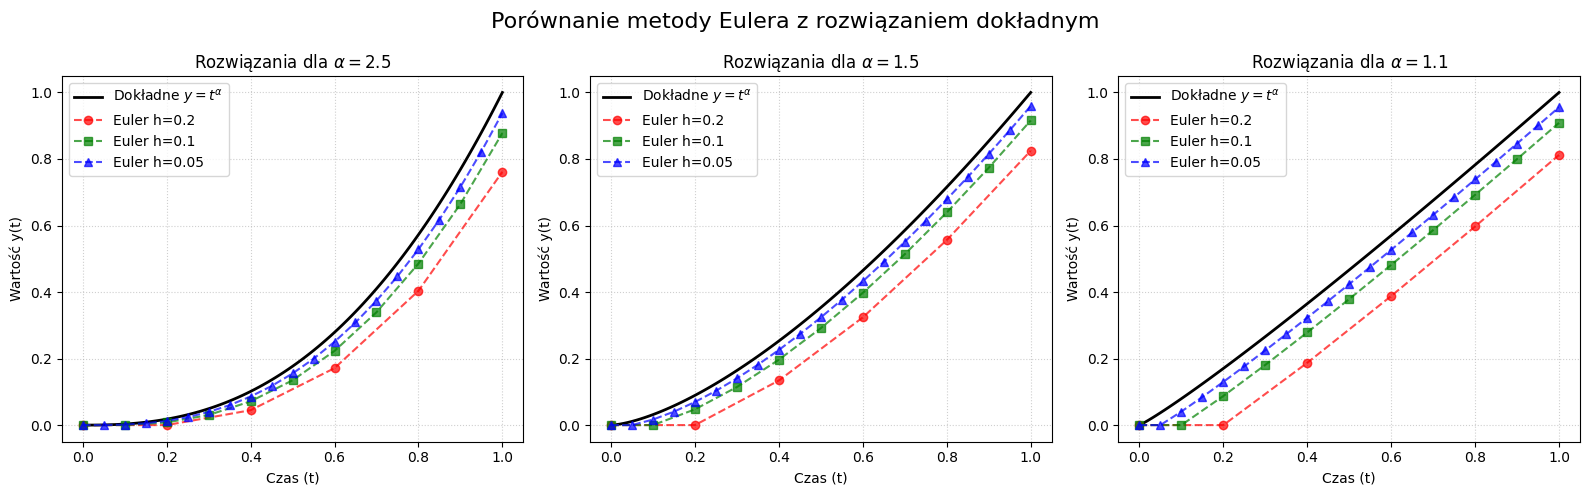

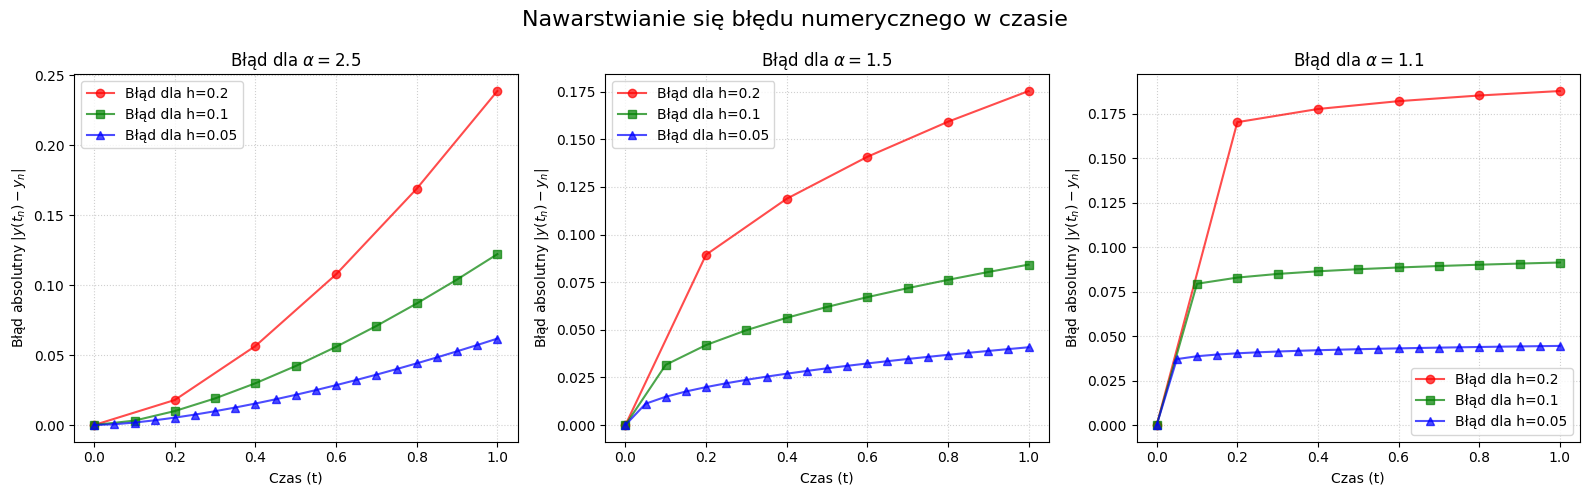

In [ ]:
colors = ["red", "green", "blue", "orange"]
markers = ["o", "s", "^", "*"]

fig1, axes1 = plt.subplots(1, 3, figsize=(16, 5))
fig1.suptitle("Porównanie metody Eulera z rozwiązaniem dokładnym", fontsize=16)

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle("Nawarstwianie się błędu numerycznego w czasie", fontsize=16)

for i, alpha in enumerate(alphas):
    ax1 = axes1[i]
    ax2 = axes2[i]

    dense_t = [j * t_end / 100 for j in range(101)]
    dense_y = [exact_solution_at_t(alpha, t) for t in dense_t]
    ax1.plot(
        dense_t, dense_y, label="Dokładne $y=t^{\\alpha}$", color="black", linewidth=2
    )

    for idx, h in enumerate(hs):
        t_vals, y_num_vals, err_vals = results[alpha][h]

        ax1.plot(
            t_vals,
            y_num_vals,
            color=colors[idx],
            marker=markers[idx],
            linestyle="--",
            alpha=0.7,
            label=f"Euler h={h}",
        )

        ax2.plot(
            t_vals,
            err_vals,
            color=colors[idx],
            marker=markers[idx],
            linestyle="-",
            alpha=0.7,
            label=f"Błąd dla h={h}",
        )

    ax1.set_title(f"Rozwiązania dla $\\alpha = {alpha}$")
    ax1.set_xlabel("Czas (t)")
    ax1.set_ylabel("Wartość y(t)")
    ax1.legend()
    ax1.grid(True, linestyle=":", alpha=0.6)

    ax2.set_title(f"Błąd dla $\\alpha = {alpha}$")
    ax2.set_xlabel("Czas (t)")
    ax2.set_ylabel("Błąd absolutny $|y(t_n) - y_n|$")
    ax2.legend()
    ax2.grid(True, linestyle=":", alpha=0.6)

fig1.tight_layout()
fig2.tight_layout()

plt.show()


# Omówienie Otrzymanych Wyników 

## Warunek gładkości
Standardowa teoria mówi, że jawna metoda Eulera ma rząd zbieżności $p=1$, o ile rozwiązanie jest dwukrotnie różniczkowalne w sposób ciągły (tzn. $y''(t)$ jest ograniczone).
Obliczmy drugą pochodną naszego rozwiązania: $y''(t) = \alpha(\alpha-1)t^{\alpha-2}$.
Dla $\alpha = 2.5$: Pochodna $y''(t) = 3.75 t^{0.5}$ jest ciągła i ograniczona na zadanym przedziale. Metoda nie napotyka żadnych osobliwości i bez problemu osiąga swój teoretyczny rząd zbieżności $EOC \approx 1$.
Dla $\alpha = 1.5$ oraz $\alpha = 1.1$: Wykładnik $\alpha - 2$ staje się ujemny. Oznacza to, że funkcja $y''(t)$ dąży do nieskończoności, gdy $t \to 0$. Rozwiązanie traci gładkość w zerze.

## Wyjaśnienie zjawiska
Zazwyczaj utrata gładkości prowadzi do drastycznego spadku rzędu zbieżności metody numerycznej. Jednak w naszym specyficznym przypadku (gdzie błąd to tak naprawdę błąd sumy prostokątów dla funkcji), błąd rozwija się asymptotycznie w szereg postaci $C_1 h + C_2 h^\alpha$.
Ponieważ we wszystkich przypadkach w zadaniu $\alpha > 1$, dla odpowiednio małego kroku $h \in (0, 1)$ zachodzi relacja $h^1 > h^\alpha$. Oznacza to, że człon liniowy błędu (związany z gładką częścią całki) opada najwolniej i ostatecznie to on dominuje. Dlatego też, wbrew pozorom wywołanym osobliwością w zerze, metoda ostatecznie i tak dąży do jedynkowego rzędu zbieżności.